In [75]:
import pandas as pd
import numpy as np

In [76]:
df = pd.read_csv("placement.csv")
df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [77]:
df.head(10)

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
5,7.89,2.99
6,6.73,2.60
7,6.75,2.48
8,6.09,2.31
9,8.31,3.51


In [78]:
X = df.iloc[:,0:1]
X

,cgpa
0,6.89
1,5.12
2,7.82
3,7.42
4,6.94
...,...
195,6.93
196,5.89
197,7.21
198,7.63


In [79]:
y = df.iloc[:,-1]
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [80]:
from sklearn.model_selection import train_test_split

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)

In [82]:
X_train

,cgpa
82,5.58
160,7.13
97,5.98
111,5.42
154,7.08
...,...
179,7.14
172,6.93
110,8.18
192,8.25


In [83]:
from sklearn.linear_model import LinearRegression

In [84]:
lr = LinearRegression()

In [85]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.59]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['cgpa']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.144
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [86]:
y_predict = lr.predict(X_test)
y_predict

array([2.50134285, 3.67282376, 1.88289608, 2.63216813, 2.97707114,
       3.00680416, 2.87003227, 3.87500828, 1.88884268, 1.57367269,
       3.53605188, 3.39333339, 2.38835738, 4.2318045 , 1.90073589,
       2.81651284, 3.10789642, 3.09005661, 2.11481362, 2.70352737,
       2.55486228, 4.2436977 , 3.00085755, 3.08411   , 3.99988696,
       3.2387217 , 3.23277509, 2.59648851, 1.74017759, 4.16639186,
       3.22088189, 3.35765377, 3.83338206, 2.01966796, 4.43398902,
       2.88787208, 2.97707114, 3.54794508, 3.66687716, 3.70255678])

In [87]:
y_test

106    2.19
31     3.89
44     1.86
33     2.73
142    3.04
155    3.09
7      2.48
83     3.49
123    2.30
193    1.94
45     3.58
80     3.44
28     2.24
116    3.33
1      1.98
105    2.82
29     3.49
117    2.99
61     1.61
157    2.70
91     2.14
164    3.82
75     3.28
90     2.66
168    3.52
152    3.08
64     2.92
176    3.23
143    1.54
163    3.91
34     3.42
148    3.40
52     4.11
10     1.86
40     4.02
127    3.11
13     2.89
5      2.99
87     3.55
178    3.63
Name: package, dtype: float64

In [88]:
from sklearn.metrics import r2_score

In [89]:
r2 = r2_score(y_test, y_predict)
r2

0.7786968891440696

## following is the calculation of R2adjusted Score, R2adjusted score is always less than R2 Score

In [90]:
1-((1-r2)*(40-1))/(40-1-1)

0.7728731230689136

## Now we will add some irelevant column to our data frame

## and we will calculate the r2score and adjusted r2 score

In [91]:
new_df = df.copy()
new_df

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [92]:
new_df['random_feature'] = np.random.random(200)
new_df

,cgpa,package,random_feature
0,6.89,3.26,0.822552
1,5.12,1.98,0.693048
2,7.82,3.25,0.988472
3,7.42,3.67,0.927590
4,6.94,3.57,0.176335
...,...,...,...
195,6.93,2.46,0.283284
196,5.89,2.57,0.145365
197,7.21,3.24,0.958554
198,7.63,3.96,0.654721


In [93]:
new_df = new_df[['cgpa', 'random_feature', 'package']]
new_df

,cgpa,random_feature,package
0,6.89,0.822552,3.26
1,5.12,0.693048,1.98
2,7.82,0.988472,3.25
3,7.42,0.927590,3.67
4,6.94,0.176335,3.57
...,...,...,...
195,6.93,0.283284,2.46
196,5.89,0.145365,2.57
197,7.21,0.958554,3.24
198,7.63,0.654721,3.96


In [94]:
import matplotlib.pyplot as plt

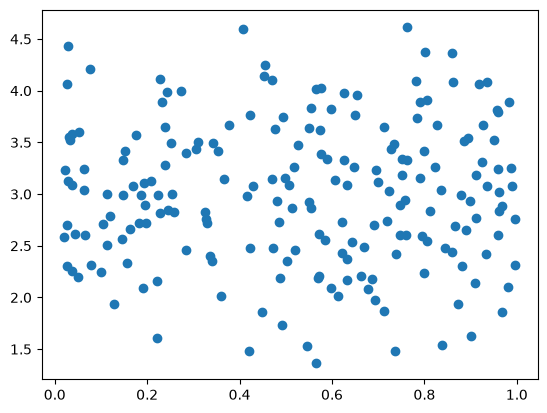

In [95]:
plt.scatter(new_df['random_feature'], new_df['package'])

In [96]:
X = new_df.iloc[:,0:2]
X

,cgpa,random_feature
0,6.89,0.822552
1,5.12,0.693048
2,7.82,0.988472
3,7.42,0.927590
4,6.94,0.176335
...,...,...
195,6.93,0.283284
196,5.89,0.145365
197,7.21,0.958554
198,7.63,0.654721


In [97]:
y = new_df.iloc[:, -1]
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [98]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)

In [99]:
X_train

,cgpa,random_feature
13,6.93,0.195755
100,7.95,0.453440
136,5.64,0.981384
7,6.75,0.421881
80,7.63,0.727868
...,...,...
103,7.05,0.112947
2,7.82,0.988472
23,6.19,0.473049
185,6.31,0.912234


In [100]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.58,0.12]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['cgpa','random_feature']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-1.098
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [101]:
y_pred = lr.predict(X_test)
y_pred

array([2.35073172, 2.7986143 , 2.89924798, 2.52881364, 2.56711236,
       1.94504097, 2.7309941 , 3.08438461, 2.6032384 , 3.29208175,
       3.54983778, 2.71267474, 2.95402432, 3.70156871, 3.20009016,
       4.18799034, 2.39453368, 2.92701885, 3.39255518, 4.41682041,
       2.93995818, 3.39263327, 3.49985432, 2.60974104, 3.38281541,
       2.18317813, 3.18250614, 2.78172301, 3.4876189 , 3.8824875 ,
       2.76034687, 1.95332578, 3.05781327, 3.57095707, 2.94596692,
       3.18049412, 2.19048726, 3.6495574 , 2.98029622, 4.12430383])

In [102]:
y_test

56     2.74
11     2.60
16     2.35
8      2.31
144    2.42
123    2.30
95     2.79
134    2.83
150    2.73
148    3.40
5      2.99
99     3.24
21     2.93
26     3.42
30     3.26
164    3.82
126    2.60
32     3.08
65     3.81
50     4.43
76     3.15
86     2.77
153    3.99
187    2.44
104    3.74
162    2.55
129    3.12
6      2.60
194    3.67
168    3.52
121    3.02
66     1.63
29     3.49
189    4.06
18     2.98
125    3.16
82     2.17
178    3.63
155    3.09
77     4.60
Name: package, dtype: float64

In [103]:
r2 = r2_score(y_test, y_pred)
r2

0.7562546147765846

In [104]:
1-((1-r2))*(40-1)/(40-1-2)

0.7430791885482919

## now we will add one relevant column to the data frame

In [105]:
new_df2 = df.copy()
new_df2

,cgpa,package
0,6.89,3.26
1,5.12,1.98
2,7.82,3.25
3,7.42,3.67
4,6.94,3.57
...,...,...
195,6.93,2.46
196,5.89,2.57
197,7.21,3.24
198,7.63,3.96


In [106]:
new_df2['iq'] = new_df2['package'] + (np.random.randint(-12,12, 200)/10)
new_df2

,cgpa,package,iq
0,6.89,3.26,3.16
1,5.12,1.98,2.88
2,7.82,3.25,2.15
3,7.42,3.67,4.67
4,6.94,3.57,3.57
...,...,...,...
195,6.93,2.46,2.96
196,5.89,2.57,1.77
197,7.21,3.24,2.94
198,7.63,3.96,4.36


In [107]:
new_df2 = new_df2[['cgpa', 'iq', 'package']]
new_df2

,cgpa,iq,package
0,6.89,3.16,3.26
1,5.12,2.88,1.98
2,7.82,2.15,3.25
3,7.42,4.67,3.67
4,6.94,3.57,3.57
...,...,...,...
195,6.93,2.96,2.46
196,5.89,1.77,2.57
197,7.21,2.94,3.24
198,7.63,4.36,3.96


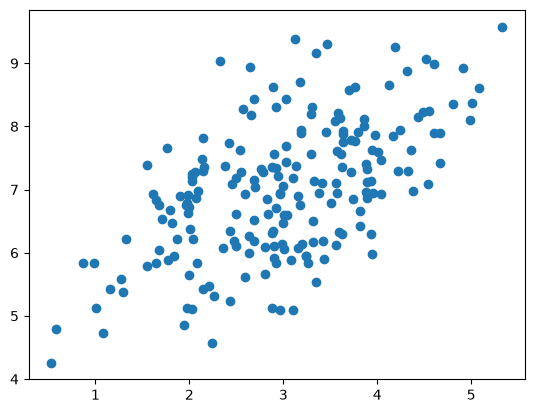

In [108]:
plt.scatter(new_df2['iq'], new_df2['cgpa'])

In [109]:
X = new_df2.iloc[:,0:2]
X

,cgpa,iq
0,6.89,3.16
1,5.12,2.88
2,7.82,2.15
3,7.42,4.67
4,6.94,3.57
...,...,...
195,6.93,2.96
196,5.89,1.77
197,7.21,2.94
198,7.63,4.36


In [110]:
y = new_df2.iloc[:, -1]
y

0      3.26
1      1.98
2      3.25
3      3.67
4      3.57
       ... 
195    2.46
196    2.57
197    3.24
198    3.96
199    2.33
Name: package, Length: 200, dtype: float64

In [111]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = .2)

In [112]:
lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.51,0.13]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['cgpa','iq']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-0.9903
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(2)


In [113]:
y_pred = lr.predict(X_test)
y_pred

array([3.23709382, 3.66349547, 2.48192353, 3.03198091, 3.88570435,
       3.0128002 , 3.0866976 , 2.744805  , 3.83175002, 2.79763686,
       2.56107076, 3.06018111, 2.98671005, 2.81262277, 2.1265264 ,
       2.57930966, 2.42830643, 2.42682627, 3.46067085, 3.15054458,
       2.02997008, 4.21687328, 2.22198192, 2.43869408, 2.53188419,
       3.15036513, 3.19879985, 2.72261699, 3.03341651, 2.99478652,
       2.74715953, 2.7161339 , 3.94199153, 3.91731289, 3.10132461,
       3.54762477, 2.4164615 , 2.95256511, 3.30829947, 3.46760318])

In [114]:
y_test

177    3.64
194    3.67
42     2.54
4      3.57
159    4.08
103    3.00
197    3.24
93     3.08
192    3.75
35     2.87
187    2.44
30     3.26
15     3.23
58     3.09
145    2.18
33     2.73
47     3.26
146    2.46
108    3.54
34     3.42
10     1.86
77     4.60
60     2.19
170    2.87
190    2.69
188    3.08
156    3.13
107    2.59
54     3.09
119    2.65
176    3.23
157    2.70
116    3.33
115    4.21
191    3.48
128    3.34
126    2.60
113    2.37
118    2.88
5      2.99
Name: package, dtype: float64

In [115]:
r2 = r2_score(y_test, y_pred)
r2

0.695708659995447

In [116]:
1-((1-r2))*(40-1)/(40-1-2)

0.6792604794546604